In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import re

from plotly.tools import mpl_to_plotly
import plotly.io as pio
from tracker.iou import *

In [2]:
prefix = "N2_Naive1"
with open(os.path.join("data", '{}_trackers.json'.format(prefix)), "r") as f:
    all_trackers = json.load(f)
long_dfs = pd.read_csv(os.path.join("data",'{}_dfs.csv'.format(prefix)), index_col="frame")
long_dfs.index = long_dfs.index.astype(int)
all_trackers = {int(k): v for k, v in all_trackers.items()}

trackers_summarize = generate_summarize(all_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(trackers_summarize)):
    tmp_df = trackers_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, all_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_trackers_summarize = pd.merge(trackers_summarize, trackers_type_df, on="num")

In [3]:
split_from_df = pd.concat([split_from(i, merge_trackers_summarize) for i in range(len(merge_trackers_summarize))], ignore_index=True)
split_from_df = split_from_df.loc[split_from_df.is_split == True]
tmp_all_num = []
for i in range(len(split_from_df)):
    nex_num = split_from_df.iloc[i].nex_num
    diff = split_from_df.iloc[i]['difference']
    nex_start = split_from_df.iloc[i]["nex_start"]
    this_num = split_from_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_split_df = pd.concat(tmp_all_num, ignore_index=True)

In [4]:
new_trackers = {}
ini_indx = 0
for i in range(len(all_trackers)):
    if i not in critical_split_df.tracker_num.values:
        new_trackers[ini_indx] = all_trackers[i]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_split_df, all_trackers)
        for j in split_result:
            new_trackers[ini_indx] = j
            ini_indx += 1


In [5]:
new_summarize = generate_summarize(new_trackers)
trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize)):
    tmp_df = new_summarize.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
    
merge_new_summarize = pd.merge(new_summarize, trackers_type_df, on="num")

In [6]:
merge_to_df = pd.concat([merge_to(i, merge_new_summarize) for i in range(len(merge_new_summarize))], ignore_index=True)
merge_to_df = merge_to_df.loc[merge_to_df.is_merge == True]
tmp_all_num = []
for i in range(len(merge_to_df)):
    diff = merge_to_df.iloc[i]['difference']
    nex_start = merge_to_df.iloc[i]["nex_end"]
    this_num = merge_to_df.iloc[i].this_num

    tmp_df = pd.DataFrame(columns=['tracker_num', 'split_frame'])

    for i,j in zip(nex_start, diff):
        if j != 0:
            tmp_df.loc[len(tmp_df)] = [this_num, i]
    tmp_all_num.append(tmp_df)
    # print(tmp_df)
critical_merge_df = pd.concat(tmp_all_num, ignore_index=True)
critical_merge_df.split_frame += 1

In [7]:
new_trackers_2 = {}
ini_indx = 0
for i in range(len(new_trackers)):
    if i not in critical_merge_df.tracker_num.values:
        new_trackers_2[ini_indx] = new_trackers[(i)]
        ini_indx += 1
    else:
        split_result = split_trackers(i, critical_merge_df, new_trackers)
        for j in split_result:
            new_trackers_2[ini_indx] = j
            ini_indx += 1


In [9]:
new_summarize_2 = generate_summarize(new_trackers_2)

trackers_type_df = pd.DataFrame(columns=["num", "left_type", "right_type", "left_prev", "right_next"])
for i in range(len(new_summarize_2)):
    tmp_df = new_summarize_2.iloc[i]
    tmp_left_type, tmp_right_type, left_prev, right_next = edge_type(tmp_df, long_dfs, new_trackers_2)
    trackers_type_df.loc[len(trackers_type_df)] = [tmp_df.num, tmp_left_type, tmp_right_type, left_prev, right_next]
merge_new_summarize = pd.merge(new_summarize_2, trackers_type_df, on="num")

<Axes: xlabel='frame'>

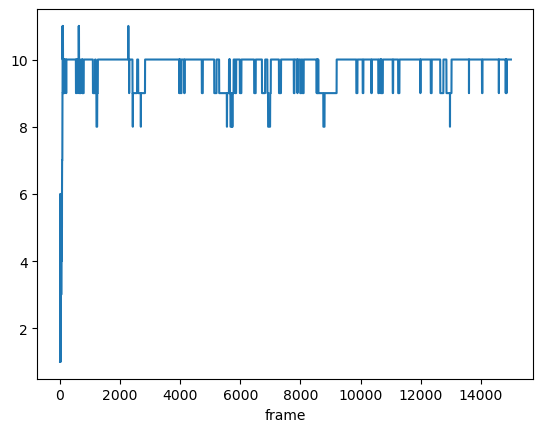

In [11]:
long_dfs.groupby('frame').size().plot()

In [17]:
all_ini = find_initial(long_dfs, 10, merge_new_summarize)
ini_indx = all_ini.sort_values(by='start_frame').num.values


In [24]:
banned_list = np.array([])
for i in range(len(all_ini)):
    exec("worm{}, banned_list = simple_find_nex(ini_indx[{}], merge_new_summarize,  banned_list)".format(i+1, i))
    if merge_new_summarize.loc[ini_indx[i]].start_frame <= 300:
        continue
    else:
        exec("worm_prev{}, banned_list = simple_find_prev(ini_indx[{}], merge_new_summarize,  banned_list)".format(i+1, i))
        exec("worm{} = np.concatenate((worm_prev{}[:-1], worm{}))".format(i+1, i+1, i+1))

$[0] all path banned
$[0] all path banned
$[47] all path banned
$[0] all path banned
$[0] all path banned
$[6] all path banned


/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:423: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Documents/code/worm_tracker/tracker/iou.py:358: FutureWarning:

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison

/Users/zhengpanpan/Docume

In [34]:
for j in range(1,11):
    print("worm{}".format(j),eval("worm{}".format(j)))

worm1 [147]
worm2 [ 95  96 104 105 106 128 129 150 151]
worm3 [  0   6   9  10  11  56  57  58  59  60  64  66  68  70  80  96  97 101
 103 105 112 121 122 134 123 136 137 142 143 156 158]
worm4 [ -1  12  23  16  42  37  39  47  48  44  50  51  53  54  62  69  72  73
  74  76  84  85  86  83  89  90 126 109 110 107 115 116 117 118 120 131
 132 141 142 155]
worm5 [ -1   4  41  42  43  52  59  61  65  66  67  70  78  79 108 117 119 120
 149 150 153]
worm6 [22 23 24 25 26 27 15 29 38 39 -1]
worm7 [ -1  20  31  46  53  55  63  69  71  73  75  76  81  85  86  87  91  93
  94  99 100 101 114 115 133 134 135 136 130 132 154]
worm8 [ 13  25  14  27  28  29  30  31  32 113 124 152]
worm9 [ -1  17  18  19  34  35  36  45  57  77  79 125 126 127 128 148]
worm10 [ -1   8  10  33  34  21  36  82  86  87  88  89  92  93  98  99 102 110
 111 121 140 156 157]


In [38]:
merge_new_summarize.loc[worm10[2]]

num                                                      10
start_frame                                             564
end_frame                                               574
durations                                                10
start_bbox                     [1727.0, 1039.0, 29.0, 18.0]
end_bbox                       [1723.0, 1042.0, 31.0, 21.0]
start_centroids    [1738.5564625850338, 1046.9986394557825]
end_centroids      [1735.6609929078013, 1049.4652482269505]
left_type                                             merge
right_type                                            split
left_prev                              ([8, 9], [563, 563])
right_next                           ([11, 33], [575, 575])
Name: 10, dtype: object